In [1]:
import sys
sys.path.insert(0, '../')
from plotting import *
setup_plotting()


## Laplace Approximation

The first technique that we will discuss is Laplace approximation. This technique can be used for reasonably well behaved functions that have most of their mass concentrated in a small area of their domain. Technically, it works for functions that are in the class of $\mathfrak{L}^2$, meaning that

$$\int g(x)^2\,dx < \infty$$

Such a function generally has very rapidly decreasing tails so that in the far reaches of the domain we would not expect to see large spikes.

Imagine a function that looks as follows

We can see that this function has most of its mass concentrated around the point $x_0$ and that we could probably approximate the area under the function with something like a step function.

The benefit of using something like a step function is that the area under a step function is trivial to compute. If we could find a principled and automatic way to find that approximating step function, and it were easier than just directly computing the integral in the first place, then we could have an alternative to computing the integral. In other words, we could perhaps say that

$$\int g(x)\,dx \approx g(x_0)\varepsilon$$

for some small value of $\varepsilon$.

In reality, we actually have some more sophisticated functions that we can use besides step functions, and that's how the Laplace approximation works. **The general idea is to take a well-behaved uni-modal function and approximate it with a Normal density function**, which is a very well-understood quantity.

Suppose we have a function $g(x)\in\mathfrak{L}^2$ which achieves its maximum at $x_0$. We want to compute

$$\int_a^b g(x)\,dx.$$

Let $h(x) = \log g(x)$ so that we have

$$\int_a^b g(x)\,dx = \int_a^b \exp(h(x))\,dx$$

From here we can take a Taylor series approximation of $h(x)$ around the point $x_0$ to give us

$$\int_a^b \exp(h(x))\,dx \approx \int_a^b\exp\left(h(x_0) + h^\prime(x_0)(x-x_0) + \frac{1}{2}h^{\prime\prime}(x_0)(x-x_0)^2\right)\,dx$$

Because we assumed $h(x)$ achieves its maximum at $x_0$, we know $h^\prime(x_0) = 0$. Therefore, we can simplify the above expression to be

$$= \int_a^b\exp\left(h(x_0) + \frac{1}{2}h^{\prime\prime}(x_0)(x-x_0)^2\right)\,dx$$

Given that $h(x_0)$ is a constant that doesn't depend on $x$, we can pull it outside the integral. In addition, we can rearrange some of the terms to give us

$$= \exp(h(x_0)) \int_a^b \exp\left(-\frac{1}{2}\frac{(x-x_0)^2}{-h^{\prime\prime}(x_0)^{-1}}\right)\,dx$$

Now that looks more like it, right? Inside the integral we have a quantity that is proportional to a Normal density with mean $x_0$ and variance $-h^{\prime\prime}(x_0)^{-1}$. At this point we are just one call to the `pnorm()` function away from approximating our integral. All we need is to compute our normalizing constants.

If we let $\Phi(x\mid \mu, \sigma^2)$ be the cumulative distribution function for the Normal distribution with mean $\mu$ and variance $\sigma^2$ (and $\varphi$ is its density function), then we can write the above expression as

$$\begin{eqnarray*}
& = & \exp(h(x_0)) \sqrt{\frac{2\pi}{-h^{\prime\prime}(x_0)}} \int_a^b \varphi(x\mid x_0,-h^{\prime\prime}(x_0)^{-1})\,dx\\
& = & \exp(h(x_0)) \sqrt{\frac{2\pi}{-h^{\prime\prime}(x_0)}} \left[ \Phi\left(b\mid x_0,-h^{\prime\prime}(x_0)^{-1}\right) - \Phi\left(a\mid x_0,-h^{\prime\prime}(x_0)^{-1}\right) \right]
\end{eqnarray*}$$

Recall that $\exp(h(x_0)) = g(x_0)$. If $b=\infty$ and $a = -\infty$, as is commonly the case, then the term in the square brackets is equal to $1$, making the Laplace approximation equal to the value of the function $g(x)$ at its mode multiplied by a constant that depends on the curvature of the function $h$.

One final note about the Laplace approximation is that it replaces the problem of integrating a function with the problem of *maximizing* it. In order to compute the Laplace approximation, we have to compute the location of the mode, which is an optimization problem. Often, this problem is faster to solve using well-understood function optimizers than integrating the same function would be.

### Computing the Posterior Mean

In Bayesian computations we often want to compute the posterior mean of a parameter given the observed data. If $y$ represents data we observe and $y$ comes from the distribution $f(y\mid\theta)$ with parameter $\theta$ and $\theta$ has a prior distribution $\pi(\theta)$, then we usually want to compute the posterior distribution $p(\theta\mid y)$ and its mean,

$$\mathbb{E}_p[\theta] = \int \theta\, p(\theta\mid y)\,d\theta.$$

We can then write

$$\begin{eqnarray*}
\int \theta\,p(\theta\mid y)\,dx & = & \frac{ \int\theta\,f(y\mid\theta)\pi(\theta)\,d\theta }{ \int f(y\mid\theta)\pi(\theta)\,d\theta }\\
& = & \frac{ \int\theta\,\exp(\log f(y\mid\theta)\pi(\theta))\,d\theta }{ \int\exp(\log f(y\mid\theta)\pi(\theta)\,d\theta) }
\end{eqnarray*}$$

Here, we've used the age old trick of exponentiating and log-ging.

If we let $h(\theta) = \log f(y\mid\theta)\pi(\theta)$, then we can use the same Laplace approximation procedure described in the previous section. However, in order to do that we must know where $h(\theta)$ achieves its maximum. Because $h(\theta)$ is simply a monotonic transformation of a function proportional to the posterior density, we know that $h(\theta)$ achieves its maximum at the *posterior mode*.

Let $\hat{\theta}$ be the posterior mode of $p(\theta\mid y)$. Then we have

$$\begin{eqnarray*}
\int \theta\,p(\theta\mid y)\,dx & \approx & \frac{ \int\theta \exp\left( h(\hat{\theta}) + \frac{1}{2}h^{\prime\prime}(\hat{\theta})(\theta-\hat{\theta})^2 \right)\,d\theta }{ \int \exp\left( h(\hat{\theta}) + \frac{1}{2}h^{\prime\prime}(\hat{\theta})(\theta-\hat{\theta})^2 \right)\,d\theta }\\
& = & \frac{ \int\theta \exp\left( \frac{1}{2}h^{\prime\prime}(\hat{\theta})(\theta-\hat{\theta})^2 \right)\,d\theta }{ \int \exp\left( \frac{1}{2}h^{\prime\prime}(\hat{\theta})(\theta-\hat{\theta})^2 \right)\,d\theta }\\
& = & \frac{ \int \theta \sqrt{\frac{2\pi}{-h^{\prime\prime}(\hat{\theta})}} \varphi\left(\theta\mid\hat{\theta},-h^{\prime\prime}(\hat{\theta})^{-1}\right) \,d\theta }{ \int \sqrt{\frac{2\pi}{-h^{\prime\prime}(\hat{\theta})}} \varphi\left(\theta\mid\hat{\theta},-h^{\prime\prime}(\hat{\theta})^{-1}\right) \,d\theta }\\
& = & \hat{\theta}
\end{eqnarray*}$$

Hence, the Laplace approximation to the posterior mean is equal to the posterior mode. This approximation is likely to work well when the posterior is unimodal and relatively symmetric around the mode. Furthermore, the more concentrated the posterior is around $\hat{\theta}$, the better.

#### Example: Poisson Data with a Gamma Prior

In this simple example, we will use data drawn from a Poisson distribution with a mean that has a Gamma prior distribution. The model is therefore

$$\begin{eqnarray*}
Y \mid \mu & \sim & \text{Poisson}(\mu)\\
\mu & \sim & \text{Gamma}(a, b)
\end{eqnarray*}$$

where the Gamma density is

$$f(\mu) = \frac{1}{b^{a}\Gamma(a)}\mu^{a - 1}e^{-\mu/b}$$

In this case, given an observation $y$, the posterior distribution is simply a Gamma distribution with shape parameter $y + a$ and scale parameter $(1 + 1/b)$.

Suppose we observe $y = 2$. We can draw the posterior distribution and prior distribution as follows.

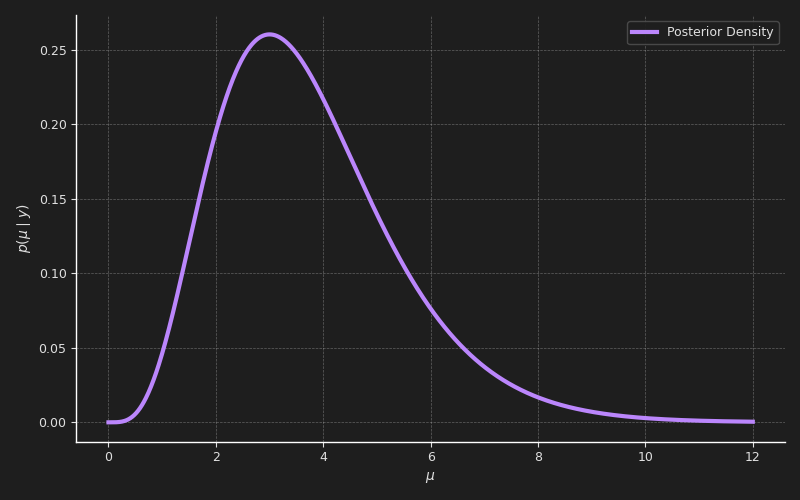

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
rng = np.random.default_rng(20171129)
y = 2
prior_shape = 3
prior_scale = 3

def make_post(y, shape, scale):
    """Create posterior Gamma density (Poisson-Gamma conjugate)"""
    post_shape = y + shape
    post_scale = 1 / (1 + 1/scale)
    return lambda x: stats.gamma.pdf(x, post_shape, scale=post_scale)

p = make_post(y, prior_shape, prior_scale)

xpts = np.linspace(0, 12, 1000)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(xpts, p(xpts), lw=3, label='Posterior Density')
ax.set_xlabel(r'$\mu$')
ax.set_ylabel(r'$p(\mu \mid y)$')
ax.legend()
plt.tight_layout()

In [3]:
pmode = (y + prior_shape - 1) * (1 / (1 + 1/prior_scale))
print(f"Posterior mode: {pmode:.4f}")

Posterior mode: 3.0000


Because this is a Gamma distribution, we can also compute the posterior mode in closed form.

In [4]:
pmean = (y + prior_shape) * (1 / (1 + 1/prior_scale))
print(f"Posterior mean: {pmean:.4f}")

Posterior mean: 3.7500


In [5]:
post_shape = y + prior_shape
post_scale = 1 / (1 + 1/prior_scale)

def logpost(mu):
    return stats.gamma.logpdf(mu, post_shape, scale=post_scale)

# Compute gradient and Hessian at mode via finite differences
def deriv1(f, x, dx=1e-5):
    return (f(x + dx) - f(x - dx)) / (2 * dx)

def deriv2(f, x, dx=1e-5):
    return (f(x + dx) - 2*f(x) + f(x - dx)) / dx**2

grad = deriv1(logpost, pmode)
hess = deriv2(logpost, pmode)
print(f"Gradient at mode: {grad:.6f}")
print(f"Hessian at mode: {hess:.4f}")

Gradient at mode: 0.000000
Hessian at mode: -0.4444



We can also compute the mean.

In [6]:
def lapprox(mu, mu0=None):
    """Laplace approximation to posterior at mu, centered at mode mu0"""
    if mu0 is None:
        mu0 = pmode
    hess = deriv2(logpost, mu0)
    return stats.norm.pdf(mu, mu0, np.sqrt(-1/hess))

lapprox_vec = np.vectorize(lapprox)

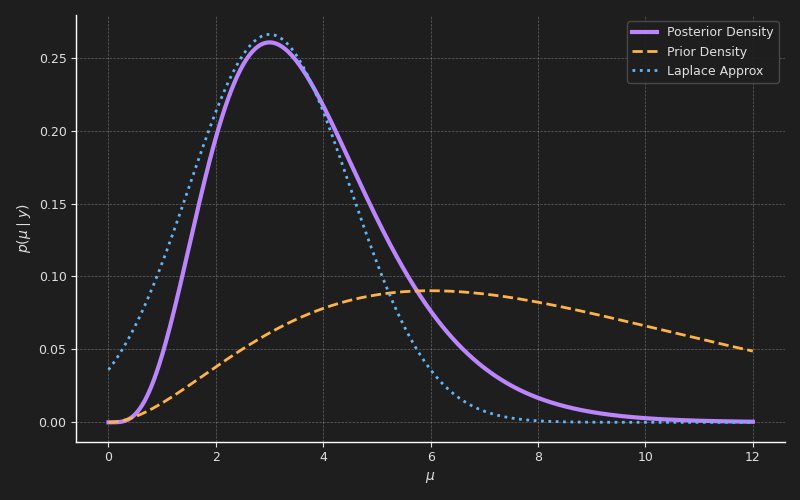

In [7]:
xpts = np.linspace(0, 12, 1000)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(xpts, p(xpts), lw=3, label='Posterior Density')
ax.plot(xpts, stats.gamma.pdf(xpts, prior_shape, scale=prior_scale), lw=2, ls='--', label='Prior Density')
ax.plot(xpts, lapprox_vec(xpts), lw=2, ls=':', label='Laplace Approx')
ax.set_xlabel(r'$\mu$')
ax.set_ylabel(r'$p(\mu \mid y)$')
ax.legend()
plt.tight_layout()

From the skewness in the figure above, it's clear that the mean and the mode should not match.

We can now see what the Laplace approximation to the posterior looks like in this case. First, we can compute the gradient and Hessian of the Gamma density.

Then we can compute the quadratic approximation to the density via the `lapprox()` function below.

Plotting the true posterior and the Laplace approximation gives us the following.

The solid red curve is the Laplace approximation and we can see that in the neighborhood of the mode, the approximation is reasonable. However, as we move farther away from the mode, the tail of the Gamma is heavier on the right.

Of course, this Laplace approximation is done with only a single observation. One would expect the approximation to improve as the sample size increases. In this case, with respect to the posterior mode as an approximation to the posterior mean, we can see that the difference between the two is simply

$$\hat{\theta}_{\text{mean}} - \hat{\theta}_{\text{mode}} = \frac{1}{n + 1/b}$$

which clearly goes to zero as $n \to \infty$.